## REGIONES

Se encontraron 73 regiones individuales.

Objeto 1: Color promedio RGB [196 135  71] -> Detectado como: Rojizo/Naranja
Objeto 2: Color promedio RGB [87 39 16] -> Detectado como: Rojizo/Naranja
Objeto 3: Color promedio RGB [102  37  14] -> Detectado como: Rojizo/Naranja
Objeto 4: Color promedio RGB [87 40 14] -> Detectado como: Rojizo/Naranja
Objeto 5: Color promedio RGB [89 39 11] -> Detectado como: Rojizo/Naranja
Objeto 6: Color promedio RGB [86 39 15] -> Detectado como: Rojizo/Naranja
Objeto 7: Color promedio RGB [93 37 10] -> Detectado como: Rojizo/Naranja
Objeto 8: Color promedio RGB [113  41  13] -> Detectado como: Rojizo/Naranja
Objeto 9: Color promedio RGB [97 35 14] -> Detectado como: Rojizo/Naranja
Objeto 10: Color promedio RGB [90 38 14] -> Detectado como: Rojizo/Naranja
Objeto 11: Color promedio RGB [91 38 11] -> Detectado como: Rojizo/Naranja
Objeto 12: Color promedio RGB [95 36 13] -> Detectado como: Rojizo/Naranja
Objeto 13: Color promedio RGB [92 38 10] -> Detectado como

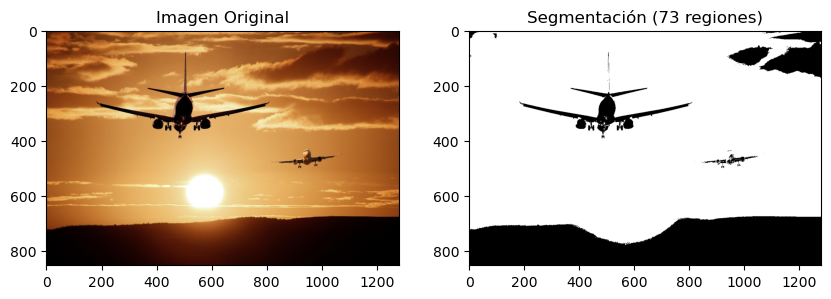

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def analizar_colores_por_region(imagen):

    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    e_img = measure.label(binary, connectivity=2)
    num_objetos = np.max(e_img)
    
    
    img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    resultados = []

   
    for i in range(1, num_objetos + 1):
        
        mask_objeto = (e_img == i)
        
       
        pixeles_objeto = img_rgb[mask_objeto]
        
       
        color_promedio = np.mean(pixeles_objeto, axis=0).astype(int)
        
        
        r, g, b = color_promedio
        etiqueta_color = "Indefinido"
        
        if r > g and r > b:
            etiqueta_color = "Rojizo/Naranja"
        elif g > r and g > b:
            etiqueta_color = "Verdoso"
        elif b > r and b > g:
            etiqueta_color = "Azulado"
            
        resultados.append({
            "id": i,
            "color_rgb": color_promedio,
            "clase": etiqueta_color
        })

    return num_objetos, resultados, binary

ruta = r'C:\pdi26\CLASE05052026\imagen1.jpg'  
img = cv2.imread(ruta)

if img is None:
    print("No se encontró la imagen.")
else:
    total, info_colores, binaria = analizar_colores_por_region(img)
    
    print(f"Se encontraron {total} regiones individuales.\n")
    
    for res in info_colores:
        print(f"Objeto {res['id']}: Color promedio RGB {res['color_rgb']} -> Detectado como: {res['clase']}")

    # Visualización
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Imagen Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    plt.subplot(1, 2, 2)
    plt.title(f"Segmentación ({total} regiones)")
    plt.imshow(binaria, cmap='gray')
    plt.show()